In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np

In [2]:
# Загрузка данных
df = pd.read_csv('/Users/luiza/Desktop/final_project/sales_ozon_20260721.csv', sep=',')

print(len(df))

2932334


In [3]:
df['purchase_datetime'] = pd.to_datetime(df['purchase_datetime'], errors='coerce')
print(df['purchase_datetime'].dtype)

datetime64[ns]


In [4]:
rfm = df.groupby('client_id').agg(
    recency=('purchase_datetime', lambda x: (datetime(2023,12,31) - x.max()).days),
    frequency=('purchase_datetime', 'count'),
    monetary=('total_price', 'sum')
)

print(rfm.head())

           recency  frequency  monetary
client_id                              
0               17          1   1302858
2               56          1     21010
3              126          7   2567105
4              297          2     33648
5              302          5   2537676


In [5]:
# Recency(чем больше, тем лучше)
rfm['r_score'], bins_r = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1], retbins=True)

# Frequency
bins_f = [0, 1, 3, 6, 10, np.inf]
labels_f = [1, 2, 3, 4, 5]
rfm['f_score'] = pd.cut(rfm['frequency'], bins=bins_f, labels=labels_f, right=False)

# Monetary
rfm['m_score'], bins_m = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5], retbins=True)

# Вывод границ
print("Границы для Recency (дни):", bins_r)
print("Границы для Frequency (количество покупок):", bins_f)
print("Границы для Monetary (сумма):", bins_m)

Границы для Recency (дни): [  0.  31.  79. 133. 210. 364.]
Границы для Frequency (количество покупок): [0, 1, 3, 6, 10, inf]
Границы для Monetary (сумма): [       0.   413964.  1186963.  2370584.  4489151. 44851167.]


In [6]:
rfm['rfm_key'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

In [7]:
# Создаем список условий
conditions = [
    # Группа 1: Чемпионы (Самые активные и частые/дорогие)
    (rfm['r_score'] == 5) & ((rfm['f_score'] == 5) | (rfm['m_score'] == 5)),
    
    # Группа 2: Перспективные (Купили недавно 1 раз, но очень дорого)
    (rfm['r_score'] >= 4) & (rfm['f_score'] == 1) & (rfm['m_score'] >= 4),
    
    # Группа 3: Новые (Купили впервые недавно дешевый товар)
    (rfm['r_score'] == 5) & (rfm['f_score'] == 1) & (rfm['m_score'] <= 2),
    
    # Группа 4: Лояльные (Постоянные, стабильные, но не дотянули до чемпионов)
    (rfm['r_score'] >= 4) & (rfm['f_score'] >= 3) & (rfm['m_score'] >= 3),
    
    # Группа 5: Засыпающие 
    (rfm['r_score'] == 3),
    
    # Группа 6: Холодные 
    (rfm['r_score'] == 2)
]

# Создаем список названий групп (строго по порядку условий)
choices = [
    'Чемпионы (VIP)',
    'Перспективные (Дорогие разовые)',
    'Новые (Дешевые разовые)',
    'Лояльные (Постоянные)',
    'Засыпающие',
    'Холодные'
]

# Все, кто не подошел ни под одно условие автоматически получат статус "Утерянные"
rfm['segment'] = np.select(conditions, choices, default='Утерянные')

In [10]:
print(rfm['segment'].value_counts())
summary_codes = rfm.groupby('segment')['rfm_key'].apply(lambda x: ', '.join(sorted(x.unique()))).reset_index()

summary_codes.columns = ['segment', 'rfm_codes']

#summary_codes.to_csv('segment_codes.csv', index=False, encoding='utf-8-sig', sep=';')

segment
Утерянные                326440
Лояльные (Постоянные)    298080
Холодные                 107825
Засыпающие                95233
Чемпионы (VIP)            42388
Name: count, dtype: int64


Когортный анализ

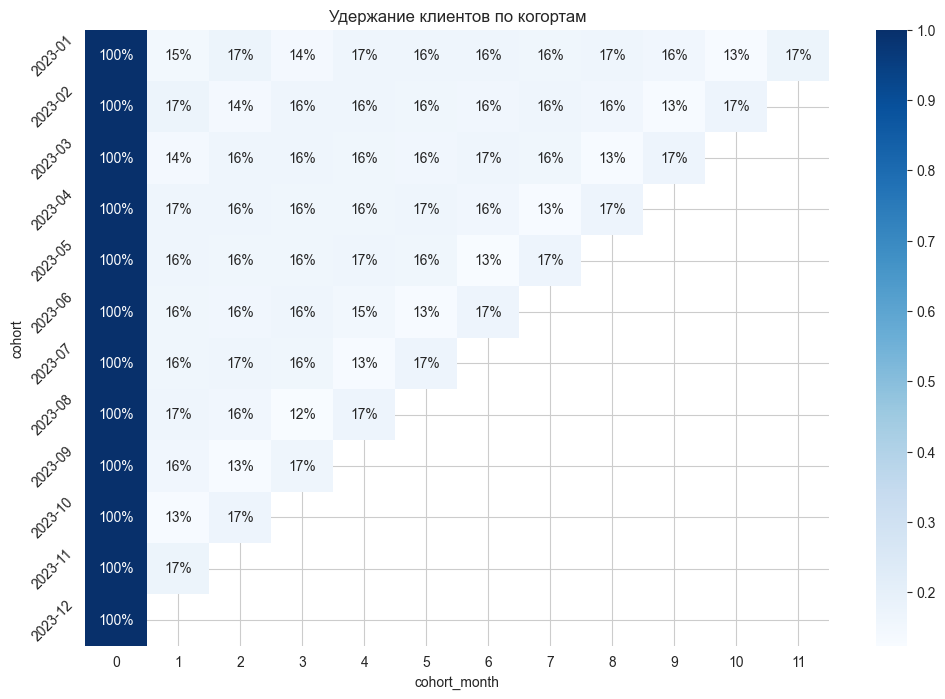

In [ ]:
# Определяем дату первой покупки для каждого клиента
first_purchase = df.groupby('client_id')['purchase_datetime'].min().reset_index()
first_purchase.columns = ['client_id', 'first_purchase']
first_purchase['cohort'] = first_purchase['first_purchase'].dt.to_period('M')

# Присоединяем когорту к основным данным
df_cohort = df.merge(first_purchase[['client_id', 'cohort']], on='client_id', how='left')

# Порядковый номер месяца относительно первой покупки
df_cohort['cohort_month'] = (df_cohort['purchase_datetime'].dt.to_period('M') - 
                             df_cohort['cohort']).apply(lambda x: x.n)

# Строим когортную таблицу удержания
cohort_retention = df_cohort.groupby(['cohort', 'cohort_month'])['client_id'].nunique().reset_index()
cohort_sizes = df_cohort.groupby('cohort')['client_id'].nunique().reset_index().rename(columns={'client_id': 'cohort_size'})
cohort_retention = cohort_retention.merge(cohort_sizes, on='cohort')
cohort_retention['retention'] = cohort_retention['client_id'] / cohort_retention['cohort_size']

# Визуализация
pivot_retention = cohort_retention.pivot(index='cohort', columns='cohort_month', values='retention')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_retention, annot=True, fmt='.0%', cmap='Blues')
plt.yticks(rotation=45, ha='right')
plt.savefig('cohort.png', dpi=300)
plt.title('Удержание клиентов по когортам')
plt.show()

In [ ]:
current_date = df['purchase_datetime'].max()

# 2. Агрегируем данные по клиентам
client_agg = df.groupby('client_id').agg(
    total_revenue=('total_price', 'sum'),
    num_purchases=('purchase_datetime', 'count'),
    first_purchase=('purchase_datetime', 'min'),
    last_purchase=('purchase_datetime', 'max')
).reset_index()


# Возраст клиента в месяцах от первой покупки до текущей даты
client_agg['age_months'] = (current_date - client_agg['first_purchase']).dt.days / 30.44 # среднее количество дней в месяце

# Средний чек
client_agg['avg_check'] = client_agg['total_revenue'] / client_agg['num_purchases']

# Частота покупок в месяц (защита от деления на ноль: если age_months < 0.1, заменяем на 0.1)
client_agg['freq_per_month'] = client_agg['num_purchases'] / client_agg['age_months'].clip(lower=0.1)

# Продолжительность жизни 
client_agg['lifetime_months_actual'] = (client_agg['last_purchase'] - client_agg['first_purchase']).dt.days / 30.44

# LTV
client_agg['ltv'] = client_agg['avg_check'] * client_agg['freq_per_month'] * client_agg['lifetime_months']

count    8.699660e+05
mean     2.764121e+06
std      3.180381e+06
min      0.000000e+00
25%      5.740475e+05
50%      1.711348e+06
75%      3.798545e+06
max      4.485117e+07
Name: ltv, dtype: float64


Рекомендации по итогам анализа вынесены в отдельный файл: https://github.com/Luizashayn/final_project/blob/833403f0b1853581e144c7a7df2f83c3515a0c38/%D0%9F%D0%BE%D1%8F%D1%81%D0%BD%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%BA%20%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D1%8F%D0%BC/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0%20%D1%81%20%D0%BA%D0%BB%D0%B8%D0%B5%D0%BD%D1%82%D1%81%D0%BA%D0%BE%D0%B9%20%D0%B1%D0%B0%D0%B7%D0%BE%D0%B9.pdf